## Notebook 3 of 5: Population-level RNA-seq comparison, MANE-exon restriction, significance test

1. [`01_overview_and_vep.ipynb`](./01_overview_and_vep.ipynb) -- setup, family-aware
   train/test split, gene/ontology descriptions, AlphaGenome reference-only overview plots,
   classical Variant Effect Prediction (VEP).
2. [`02_individual_predictions.ipynb`](./02_individual_predictions.ipynb) -- per-individual
   consensus RNA-seq, comparing two individuals, bulk prediction generation.
3. [`03_population_analysis.ipynb`](./03_population_analysis.ipynb) -- population-level
   comparison, MANE-exon restriction, single-ontology restriction, significance test.
4. [`04_modeling.ipynb`](./04_modeling.ipynb) -- trains a LogisticRegression classifier on
   MANE-exon-restricted features, a second on whole-gene-span features, and a tiny torch MLP
   on the full concatenated signal; persists all three to `notebooks/.cache/models/`.
5. [`05_evaluation.ipynb`](./05_evaluation.ipynb) -- loads the persisted models, evaluates them
   on the held-out test split, reference/variant label prediction, literature-vs-background
   variant comparison.

**This is notebook 3.** It only reads from `notebooks/.cache/predictions/` (built by notebook
2) -- it makes **no AlphaGenome API calls** and needs no `ALPHAGENOME_API_KEY`. It writes
`notebooks/.cache/analysis/significance_df.csv` and `train_exon_means.csv`, which notebook 4
loads instead of redoing this notebook's ~47GB cache read.


In [3]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path("/home/breno/I2CA/genomics")
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
os.chdir(NOTEBOOK_DIR)

from utils import setup, rna_features
from utils import predictions as predictions_utils
from alphagenome.models import dna_client

# This notebook only reads from the on-disk predictions cache built by notebook 2 -- no
# AlphaGenome API calls are made here, so no client / API key is needed.
ctx = setup.load_experiment(NOTEBOOK_DIR)
GENES, ONTOLOGY_TERMS, CLASS_MAP = ctx.GENES, ctx.ONTOLOGY_TERMS, ctx.CLASS_MAP
gene_rows, individuals, samples_by_class = ctx.gene_rows, ctx.individuals, ctx.samples_by_class
windows_df, gtf = ctx.windows_df, ctx.gtf
PREDICTIONS_CACHE_DIR = ctx.PREDICTIONS_CACHE_DIR

train_samples_by_class, test_samples_by_class = setup.get_train_test_split(individuals, CLASS_MAP)
for class_name in samples_by_class:
    print(
        f"{class_name}: {len(samples_by_class[class_name])} total -> "
        f"{len(train_samples_by_class[class_name])} train / {len(test_samples_by_class[class_name])} test"
    )

CLASS_COLORS = {
    "strong pigmentation": "red",
    "weak pigmentation": "gray",
}

ANALYSIS_CACHE_DIR = NOTEBOOK_DIR / ".cache" / "analysis"
ANALYSIS_CACHE_DIR.mkdir(parents=True, exist_ok=True)


strong pigmentation: 703 total -> 570 train / 133 test
weak pigmentation: 369 total -> 292 train / 77 test


## Population-level comparison: mean RNA-seq across the train split, all genes

Now that `notebooks/.cache/predictions/` has been fully populated (via `prepare_data.ipynb`'s Step 5
import, or notebook 2's `generate_predictions()`) for every gene x every one of the 1,072
strong/weak pigmentation individuals x both haplotypes, this compares the mean RNA-seq signal
between the two classes, for every gene -- entirely from the on-disk cache, no AlphaGenome
calls. **Only `train_samples_by_class` individuals are used** (the family-aware,
population-stratified split from notebook 1, recomputed here identically) -- the held-out test
individuals stay untouched by every analysis cell below, not just the significance test.

For each individual: H1 + H2 are summed, restricted to the gene's own transcribed strand (from the
GTF's MANE Select transcript -- summing both strands here would mix sense and antisense signal), and
the 3 cell-type ontology terms are summed into one "total signal" value per position. Those
per-individual tracks are then averaged across every train individual in each class. Plotted zoomed to
each gene's own GTF span (the same zoom `plot_rna_seq_comparison` in notebook 2 uses), not the
full 512kb window (mostly flanking sequence) or a fixed-size crop -- genes here range from ~9kb
(MC1R, TCHH) to ~344kb (OCA2), so a fixed window would cut off the larger ones.

Reads ~80% of the ~47GB cached predictions from disk (the train split only; no network/API calls) --
still takes a few minutes.


In [4]:
t0 = time.time()
population_means = {}
for gene in GENES:
    strand = rna_features.gene_strand(gtf, gene)
    population_means[gene] = {
        class_name: rna_features.class_mean_signal(PREDICTIONS_CACHE_DIR, gene, sample_ids, strand)
        for class_name, sample_ids in train_samples_by_class.items()
    }
    print(f"[{time.time() - t0:5.1f}s] {gene} ({strand} strand): "
          f"{', '.join(f'{k} n={len(v)}' for k, v in train_samples_by_class.items())}")
print(f"\nDone in {(time.time() - t0) / 60:.1f} minutes.")


[ 38.6s] MC1R (+ strand): strong pigmentation n=570, weak pigmentation n=292
[ 73.6s] TYRP1 (+ strand): strong pigmentation n=570, weak pigmentation n=292
[109.2s] TYR (+ strand): strong pigmentation n=570, weak pigmentation n=292
[146.0s] SLC45A2 (- strand): strong pigmentation n=570, weak pigmentation n=292
[183.2s] DDB1 (- strand): strong pigmentation n=570, weak pigmentation n=292
[218.8s] EDAR (- strand): strong pigmentation n=570, weak pigmentation n=292
[258.0s] MFSD12 (- strand): strong pigmentation n=570, weak pigmentation n=292
[295.8s] OCA2 (- strand): strong pigmentation n=570, weak pigmentation n=292
[332.0s] HERC2 (- strand): strong pigmentation n=570, weak pigmentation n=292
[366.8s] SLC24A5 (+ strand): strong pigmentation n=570, weak pigmentation n=292
[402.6s] TCHH (- strand): strong pigmentation n=570, weak pigmentation n=292

Done in 6.7 minutes.


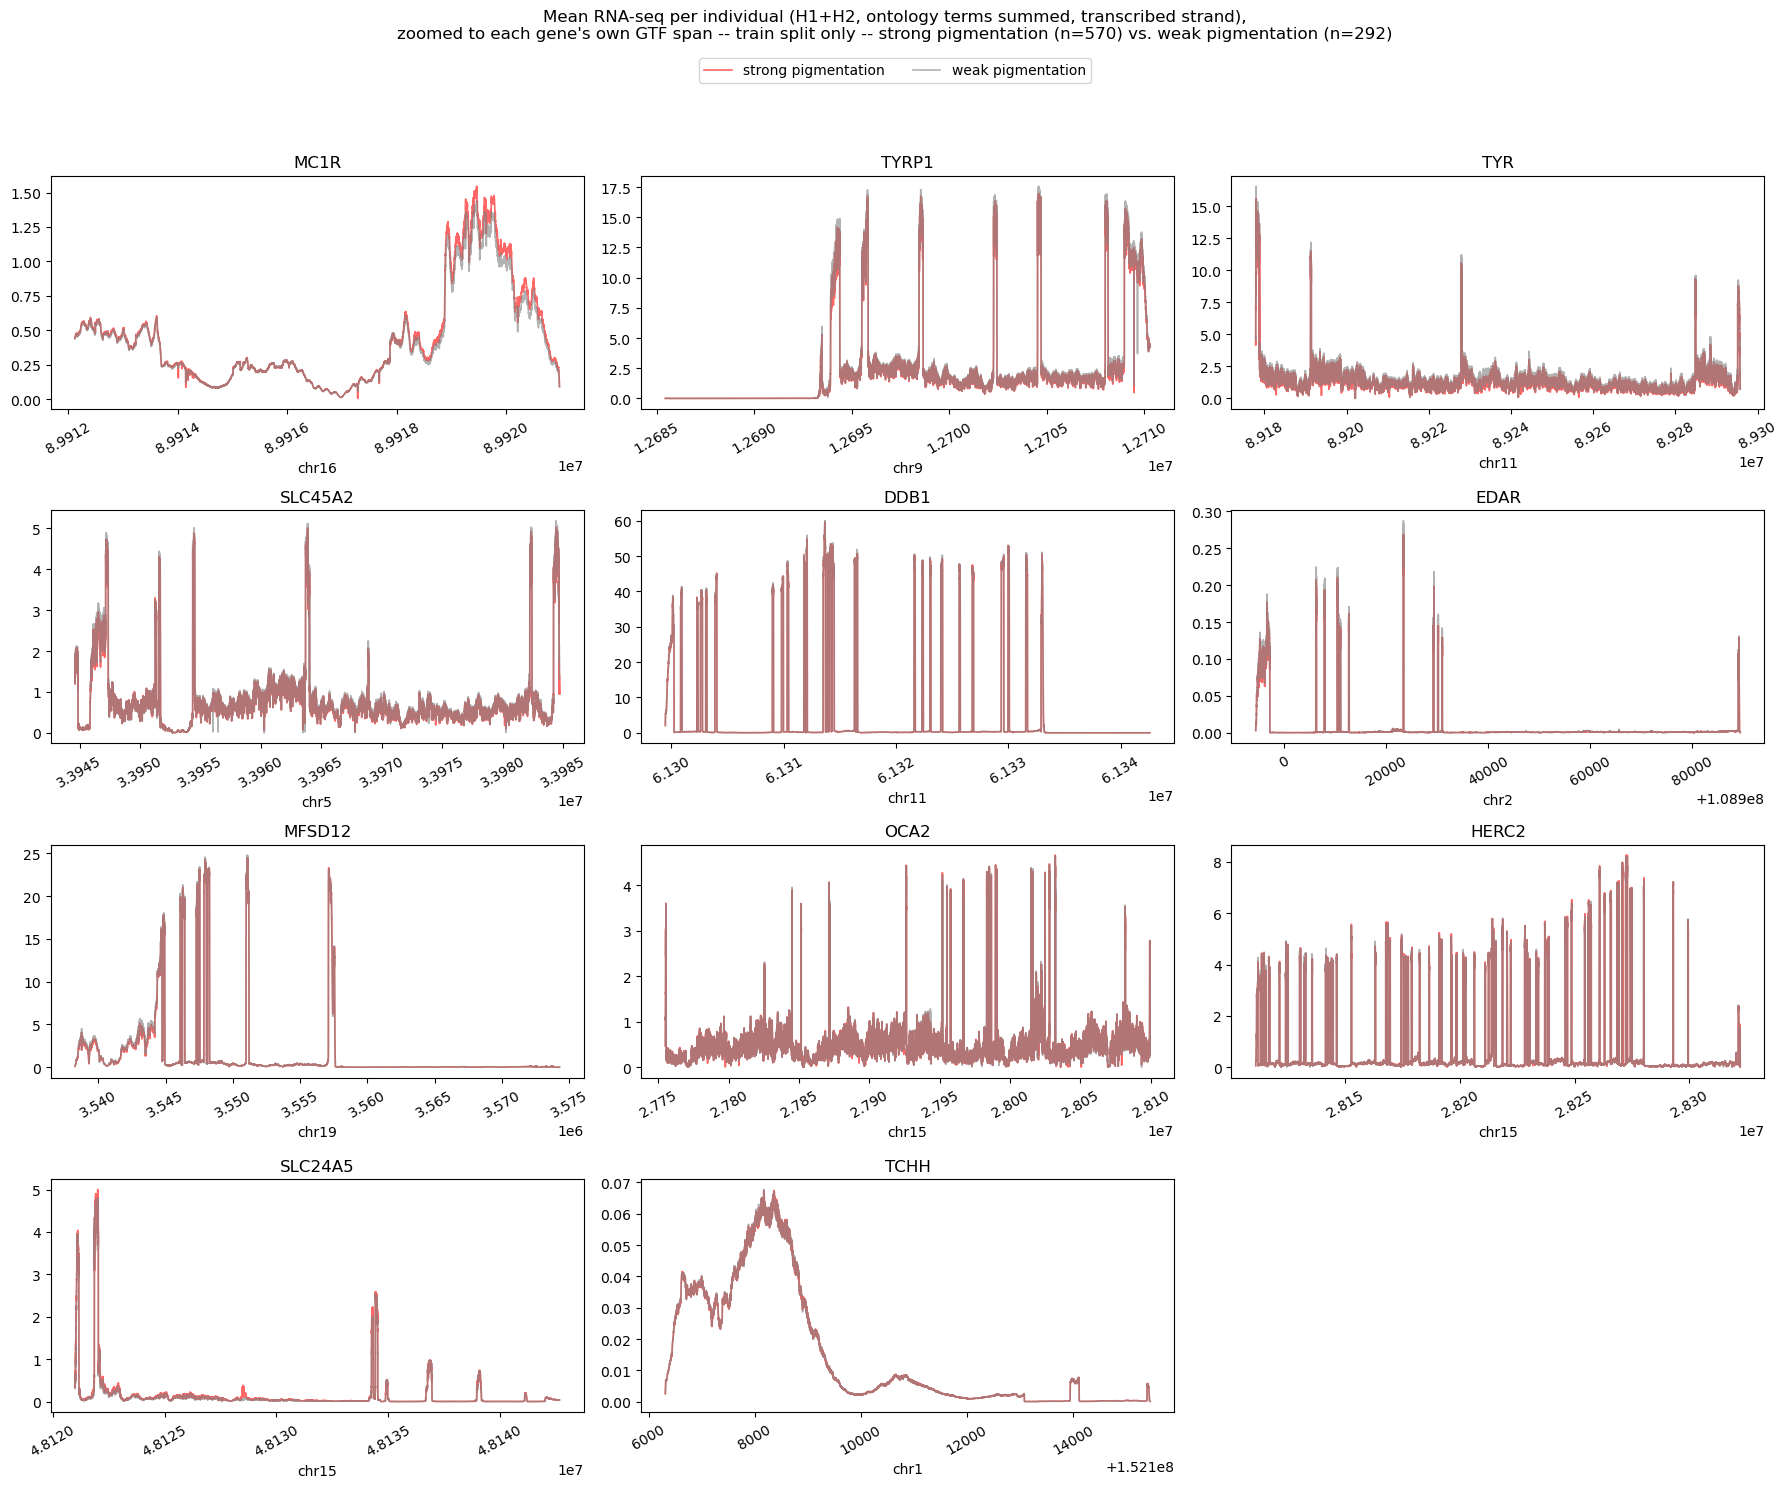

,gene,strong pigmentation,weak pigmentation,log2_fold_change (strong / weak)
0,DDB1,4.173515,4.199893,-0.009089
1,EDAR,0.005586,0.005921,-0.084087
2,HERC2,0.456167,0.454028,0.006782
3,MC1R,0.440663,0.417120,0.079213
4,MFSD12,1.506492,1.558380,-0.048854
5,OCA2,0.508452,0.507051,0.003982
6,SLC24A5,0.154090,0.139133,0.147304
7,SLC45A2,0.833649,0.867056,-0.056685
8,TCHH,0.014584,0.014605,-0.002061
9,TYR,1.547567,1.731929,-0.162378


In [5]:
fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

# Zoom to each gene's own GTF span, centered on the window (matches notebook 2's
# plot_rna_seq_comparison zoom, minus its 1.5x margin) -- not a fixed window size, since genes
# here range from ~9kb (MC1R, TCHH) to ~344kb (OCA2).
gene_zoom_slices = rna_features.compute_gene_zoom_slices(gtf, GENES, dna_client.SEQUENCE_LENGTH_500KB)

for ax, gene in zip(axes, GENES):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    lo, hi = gene_zoom_slices[gene]
    positions = np.arange(gene_data["start"], gene_data["end"])[lo:hi]

    for class_name, mean_signal in population_means[gene].items():
        ax.plot(positions, mean_signal[lo:hi], label=class_name, color=CLASS_COLORS[class_name], linewidth=1.2, alpha=0.6)
    ax.set_title(gene)
    ax.set_xlabel(gene_data["chrom"])
    ax.tick_params(axis="x", labelrotation=30)

for ax in axes[len(GENES):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
fig.suptitle(
    f"Mean RNA-seq per individual (H1+H2, ontology terms summed, transcribed strand),\n"
    f"zoomed to each gene's own GTF span -- train split only -- "
    f"strong pigmentation (n={len(train_samples_by_class['strong pigmentation'])}) vs. "
    f"weak pigmentation (n={len(train_samples_by_class['weak pigmentation'])})",
    y=1.06,
)
fig.tight_layout()
plt.show()
plt.close(fig)

summary_df = pd.DataFrame([
    {
        "gene": gene,
        "strong pigmentation": population_means[gene]["strong pigmentation"][lo:hi].mean(),
        "weak pigmentation": population_means[gene]["weak pigmentation"][lo:hi].mean(),
    }
    for gene, (lo, hi) in gene_zoom_slices.items()
]).sort_values("gene").reset_index(drop=True)
summary_df["log2_fold_change (strong / weak)"] = np.log2(
    summary_df["strong pigmentation"] / summary_df["weak pigmentation"]
)
summary_df


### Restricting to MANE Select transcript exons only

The comparison above averages the whole gene span, including introns. AlphaGenome's RNA-seq track
is a continuous per-base signal over genomic position -- summing it over the full span (even just the
MANE transcript's own TSS-to-TES) mixes in a lot of intronic signal that isn't "gene expression" in
the usual (spliced mRNA) sense.

This drops every intronic/flanking position and **glues the remaining exon positions together**, in
5'->3' order along the MANE Select transcript (reversed for `-` strand genes, so consecutive plotted
points are always adjacent on the mature mRNA even though they can be far apart -- or on the opposite
side of a large intron -- in genomic coordinates). Splice junctions are marked with light dashed
lines. Each gene gets its own full-width row so the (much narrower, exon-only) signal is actually
zoomed in enough to compare. `log2_fold_change` is recomputed over just the exon positions too. No
re-reading of the cache -- reuses `population_means` computed above.


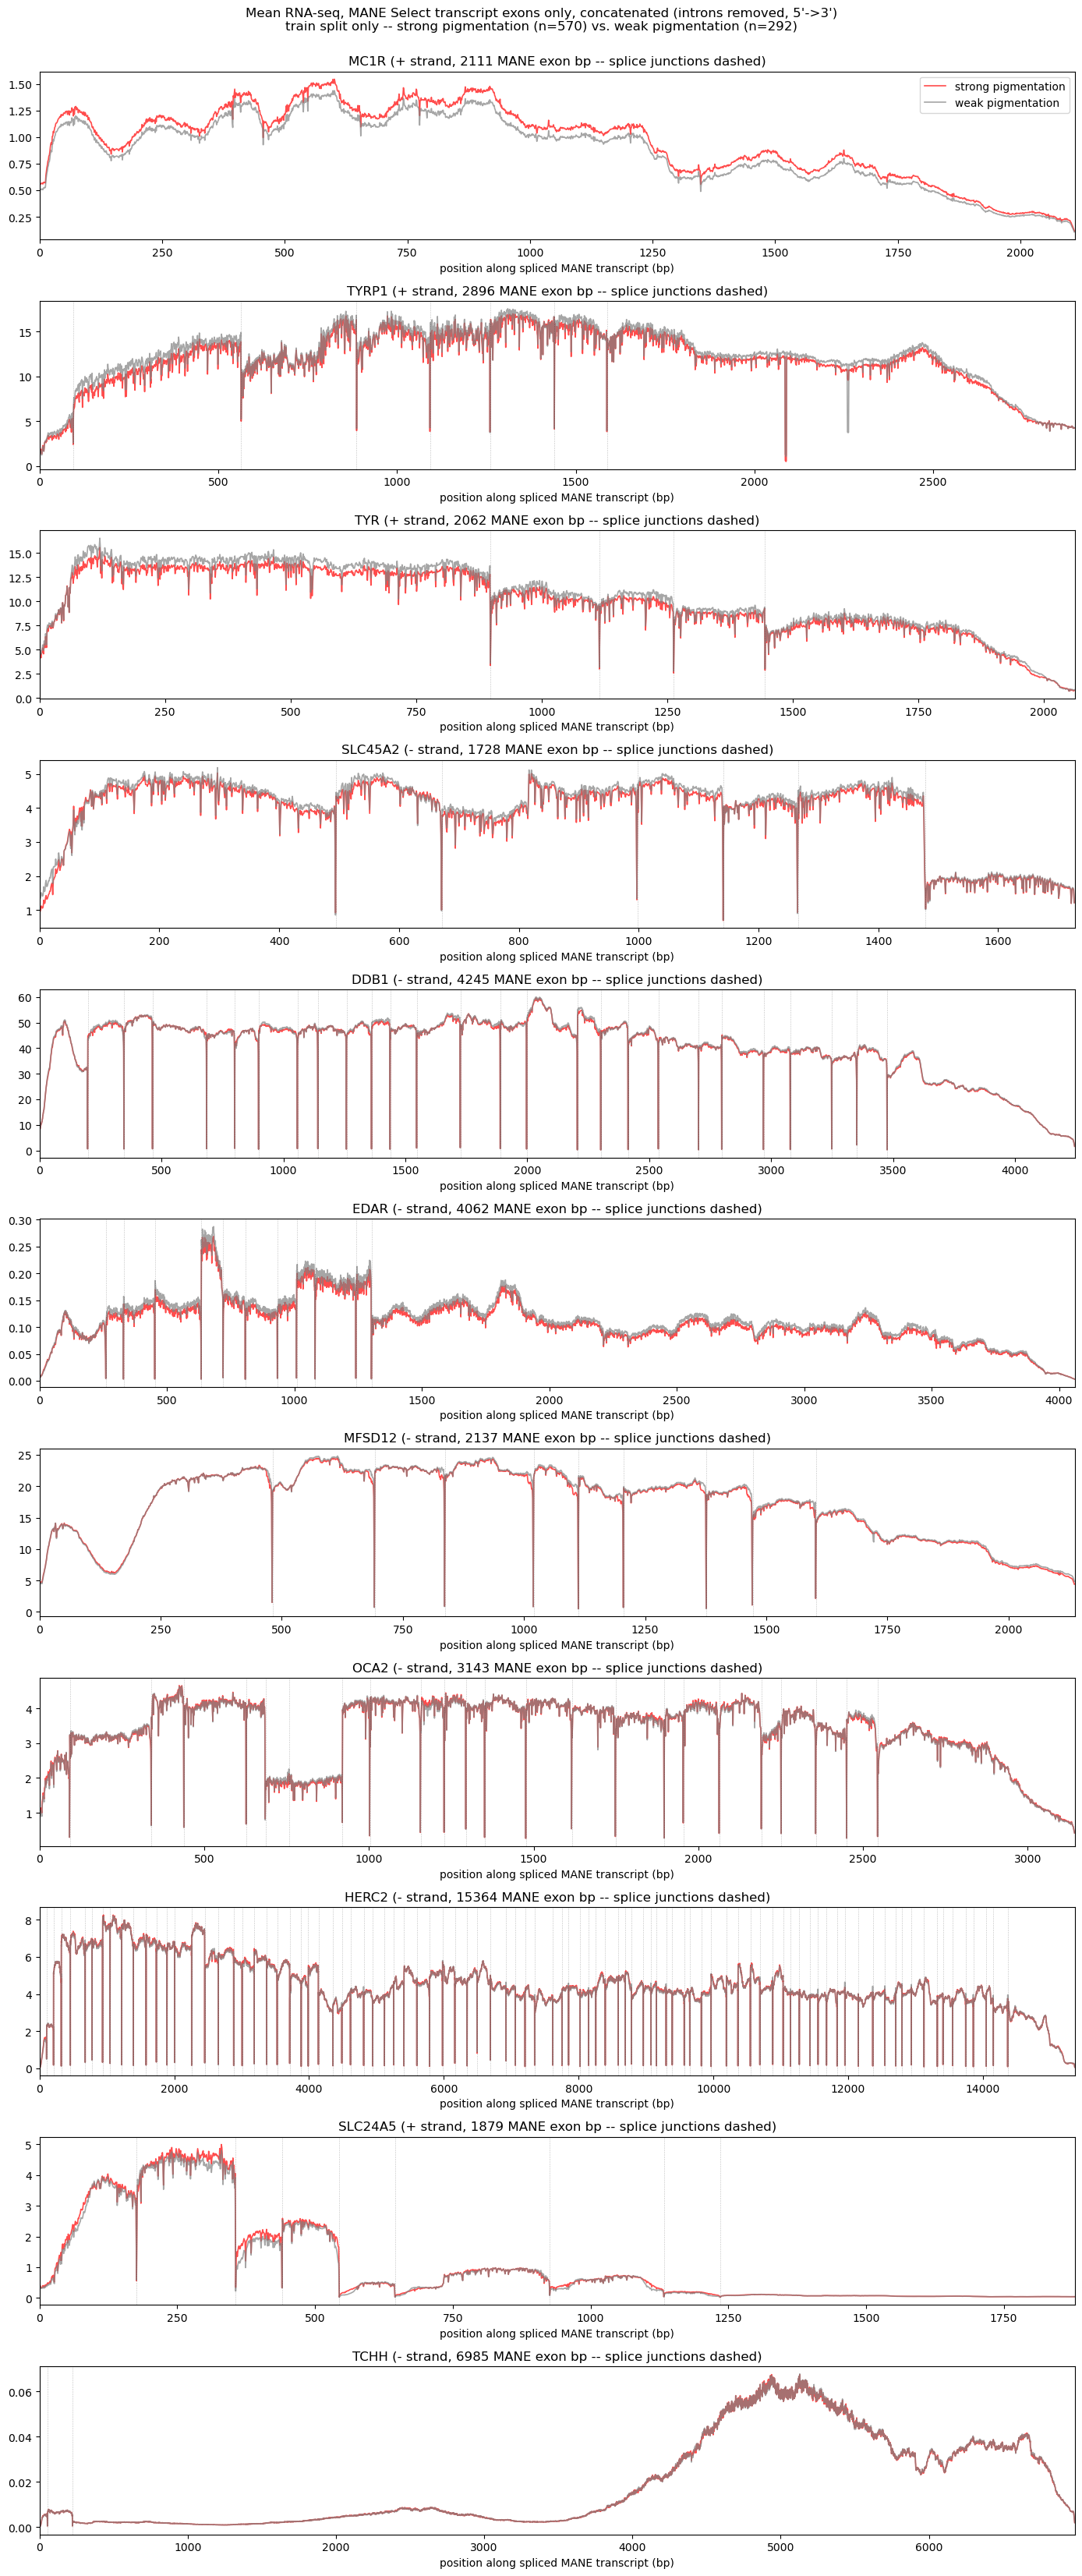

,gene,n_exon_bases,strong pigmentation,weak pigmentation,log2_fold_change (strong / weak)
0,DDB1,4245,40.610615,40.882805,-0.009637
1,EDAR,4062,0.108335,0.115378,-0.090863
2,HERC2,15364,4.548447,4.525725,0.007225
3,MC1R,2111,0.953451,0.877556,0.119669
4,MFSD12,2137,17.126247,17.314095,-0.015738
5,OCA2,3143,3.360044,3.356816,0.001387
6,SLC24A5,1879,1.090904,1.045976,0.060674
7,SLC45A2,1728,3.865103,3.966020,-0.037185
8,TCHH,6985,0.018982,0.019011,-0.002162
9,TYR,2062,9.923079,10.439292,-0.073164


In [6]:
fig, axes = plt.subplots(len(GENES), 1, figsize=(14, 3 * len(GENES)))

exon_masks = {}
for ax, gene in zip(axes, GENES):
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    window_size = gene_data["end"] - gene_data["start"]
    strand = rna_features.gene_strand(gtf, gene)

    exon_masks[gene] = rna_features.mane_exon_mask(gtf, gene, gene_data["start"], window_size)
    indices, boundaries = rna_features.mane_exon_indices(gtf, gene, gene_data["start"], strand)
    meta_positions = np.arange(len(indices))

    for class_name, mean_signal in population_means[gene].items():
        ax.plot(meta_positions, mean_signal[indices], label=class_name, color=CLASS_COLORS[class_name], linewidth=1.2, alpha=0.7)
    for b in boundaries:
        ax.axvline(b, color="black", linewidth=0.4, alpha=0.25, linestyle="--")
    ax.set_title(f"{gene} ({strand} strand, {len(indices)} MANE exon bp -- splice junctions dashed)")
    ax.set_xlabel("position along spliced MANE transcript (bp)")
    ax.set_xlim(0, len(indices))

axes[0].legend(loc="upper right")
fig.suptitle(
    "Mean RNA-seq, MANE Select transcript exons only, concatenated (introns removed, 5'->3')\n"
    f"train split only -- strong pigmentation (n={len(train_samples_by_class['strong pigmentation'])}) vs. "
    f"weak pigmentation (n={len(train_samples_by_class['weak pigmentation'])})",
    y=1.0,
)
fig.tight_layout()
plt.show()
plt.close(fig)

exon_summary_df = pd.DataFrame([
    {
        "gene": gene,
        "n_exon_bases": int(exon_masks[gene].sum()),
        "strong pigmentation": population_means[gene]["strong pigmentation"][exon_masks[gene]].mean(),
        "weak pigmentation": population_means[gene]["weak pigmentation"][exon_masks[gene]].mean(),
    }
    for gene in GENES
]).sort_values("gene").reset_index(drop=True)
exon_summary_df["log2_fold_change (strong / weak)"] = np.log2(
    exon_summary_df["strong pigmentation"] / exon_summary_df["weak pigmentation"]
)
exon_summary_df


### Restricting both models to a single ontology term

Everything above (the population-mean plots, the exon-restricted plot) sums all 3 cell-type
ontology terms together. From here on, both models in notebook 4 (the `LogisticRegression`
classifier and the tiny torch model) instead use **only `ONTOLOGY_TERMS[0]`** (melanocyte of
skin) -- the same one `plot_rna_seq_comparison` (`ONTOLOGY_TERM_FOR_COMPARISON` in notebook 2)
and the VEP section in notebook 1 already use, rather than summing in the two hair-follicle cell
types too. `MODEL_ONTOLOGY_TERMS` is the single knob controlling this (redefined identically in
notebook 4 -- widen it back to `ONTOLOGY_TERMS` (or any other subset) in both places to revisit
that choice).


In [7]:
MODEL_ONTOLOGY_TERMS = [ONTOLOGY_TERMS[0]]  # both models in notebook 4 use only this ontology term
print(f"Both models in notebook 4 restricted to: {MODEL_ONTOLOGY_TERMS}")


Both models in notebook 4 restricted to: ['CL:1000458']


## Statistical significance: strong vs. weak pigmentation, per gene

`log2_fold_change` above is a ratio of two point estimates (the class-mean signal) -- it says nothing
about whether the difference is larger than individual-to-individual noise. `class_mean_signal()`
only ever kept the running class average, not each individual's own value, so there's nothing to test
significance against yet.

This computes one scalar per **individual** (mean RNA-seq signal, MANE exons only, same restriction as
above) instead of collapsing straight to the class mean, then runs a Mann-Whitney U test per gene
(rank-based -- expression-like signal is typically non-normal/zero-inflated, so this is more
appropriate than a t-test) comparing the two classes' per-individual values. P-values are
Benjamini-Hochberg FDR-corrected across the 11 genes tested.

**Uses `train_samples_by_class` only** -- these p-values pick which genes feed the classifier in
notebook 4, so computing them over the full population (including the held-out test individuals)
would leak test information into gene selection.

This re-reads the same ~47GB cache (the per-individual scalars weren't kept the first time around),
so it takes a few minutes again -- somewhat less than before since it now covers ~80% of individuals.
Results (`significance_df` and the per-individual scalars) are persisted below so notebook 4 doesn't
need to redo this pass.


In [8]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


t0 = time.time()
significance_rows = []
gene_individual_means = {}  # gene -> {class_name: per-individual exon-mean array}, TRAIN split only
for gene in GENES:
    gene_data = windows_df.loc[windows_df["gene"] == gene].iloc[0]
    window_size = gene_data["end"] - gene_data["start"]
    strand = rna_features.gene_strand(gtf, gene)
    mask = rna_features.mane_exon_mask(gtf, gene, gene_data["start"], window_size)

    per_individual = {
        class_name: rna_features.individual_exon_means(
            PREDICTIONS_CACHE_DIR, gene, sample_ids, strand, mask, MODEL_ONTOLOGY_TERMS
        )
        for class_name, sample_ids in train_samples_by_class.items()
    }
    gene_individual_means[gene] = per_individual
    strong_vals = per_individual["strong pigmentation"]
    weak_vals = per_individual["weak pigmentation"]

    statistic, p_value = mannwhitneyu(strong_vals, weak_vals, alternative="two-sided")
    significance_rows.append({
        "gene": gene,
        "n_strong": len(strong_vals),
        "n_weak": len(weak_vals),
        "strong pigmentation (mean)": strong_vals.mean(),
        "weak pigmentation (mean)": weak_vals.mean(),
        "mannwhitney_u": statistic,
        "p_value": p_value,
    })
    print(f"[{time.time() - t0:5.1f}s] {gene}: done")

print(f"\nDone in {(time.time() - t0) / 60:.1f} minutes.")

significance_df = pd.DataFrame(significance_rows).sort_values("gene").reset_index(drop=True)
significance_df["log2_fold_change (strong / weak)"] = np.log2(
    significance_df["strong pigmentation (mean)"] / significance_df["weak pigmentation (mean)"]
)
_, fdr_q, _, _ = multipletests(significance_df["p_value"], method="fdr_bh")
significance_df["fdr_q_value"] = fdr_q
significance_df["significant (q < 0.05)"] = significance_df["fdr_q_value"] < 0.05
significance_df


[ 36.6s] MC1R: done
[ 69.5s] TYRP1: done
[103.7s] TYR: done
[139.1s] SLC45A2: done
[175.0s] DDB1: done
[209.3s] EDAR: done
[247.2s] MFSD12: done
[283.9s] OCA2: done
[319.0s] HERC2: done
[352.9s] SLC24A5: done
[387.9s] TCHH: done

Done in 6.5 minutes.


,gene,n_strong,n_weak,strong pigmentation (mean),weak pigmentation (mean),mannwhitney_u,p_value,log2_fold_change (strong / weak),fdr_q_value,significant (q < 0.05)
0,DDB1,570,292,9.091590,9.134183,66786.0,2.034955e-06,-0.006743,3.197787e-06,True
1,EDAR,570,292,0.003411,0.003453,76033.0,3.778510e-02,-0.017439,4.156360e-02,True
2,HERC2,570,292,1.669527,1.663682,97100.0,6.027896e-05,0.005059,8.288356e-05,True
3,MC1R,570,292,0.320812,0.293374,133924.0,1.246300e-48,0.128991,1.370930e-47,True
4,MFSD12,570,292,6.637580,6.764541,47332.5,3.299235e-25,-0.027335,9.072896e-25,True
5,OCA2,570,292,3.273097,3.265922,86247.0,3.816956e-01,0.003166,3.816956e-01,False
6,SLC24A5,570,292,1.073528,1.029685,101117.0,2.306296e-07,0.060156,5.073852e-07,True
7,SLC45A2,570,292,3.788400,3.885542,66521.0,1.389416e-06,-0.036527,2.547263e-06,True
8,TCHH,570,292,0.008023,0.008104,75246.0,2.118607e-02,-0.014473,2.589408e-02,True
9,TYR,570,292,9.869037,10.380226,39983.0,7.749013e-36,-0.072857,4.261957e-35,True


### Persisting results for notebook 4

Notebook 4's classifier needs `significance_df` (to pick which genes are used as features) and
the per-individual exon-mean scalars just computed (`gene_individual_means`, train split only)
as its training features. Both are written to `notebooks/.cache/analysis/` here so notebook 4
can load them directly instead of repeating the ~47GB cache read above.


In [14]:
significance_df.to_csv(ANALYSIS_CACHE_DIR / "significance_df.csv", index=False)

# Long format: one row per (gene, train individual) -- this is gene_individual_means flattened.
train_exon_means_rows = [
    {"gene": gene, "sample_id": sample_id, "class_name": class_name, "exon_mean": value}
    for gene, per_class in gene_individual_means.items()
    for class_name, sample_ids in train_samples_by_class.items()
    for sample_id, value in zip(sample_ids, per_class[class_name])
]
train_exon_means_df = pd.DataFrame(train_exon_means_rows)
train_exon_means_df["exon_log_mean"] = np.log(
    train_exon_means_df["exon_mean"] + 0.001
)
train_exon_means_df.to_csv(ANALYSIS_CACHE_DIR / "train_exon_means.csv", index=False)

print(f"Wrote {ANALYSIS_CACHE_DIR / 'significance_df.csv'} ({len(significance_df)} rows)")
print(f"Wrote {ANALYSIS_CACHE_DIR / 'train_exon_means.csv'} ({len(train_exon_means_df)} rows)")


Wrote /home/breno/I2CA/genomics/notebooks/.cache/analysis/significance_df.csv (11 rows)
Wrote /home/breno/I2CA/genomics/notebooks/.cache/analysis/train_exon_means.csv (9482 rows)
